## Лабораторна робота №2.



Оцінювання даної роботи буде ураховувати якість ваших візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.

Під час виконання вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації. 

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.






Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою [titanic.csv](https://gist.github.com/michhar/2dfd2de0d4f8727f873422c5d959fff5).  
Цей датасет ви вже використовували в лабораторній роботі №1 ;)  
  
  ```NB:побудовані графіки та гістограми мають бути змістовними і візуально зрозумілими.``` 
  
  
  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



**Задача 1:** Який відсоток виживання серед чоловіків / жінок? 

In [20]:
dataset = pd.read_csv('titanic.csv')

average_age = int(dataset['Age'].mean())
dataset['Age'] = dataset['Age'].fillna(average_age)

new_dataset = dataset[["Sex", "Survived"]]
male_total = new_dataset.value_counts('Sex').loc['male']
female_total = new_dataset.value_counts('Sex').loc['female']

survived = new_dataset[new_dataset["Survived"] == 1]

male_survived = survived.value_counts("Sex").loc["male"]
female_survived = survived.value_counts("Sex").loc["female"]

male_and_female = [round((female_survived / female_total) *100, 2), round((male_survived / male_total) * 100, 2) ]
print(f"Male survived - {male_and_female[1]}%")
print(f"Female survived - {male_and_female[0]}%")



Male survived - 18.89%
Female survived - 74.2%


**Задача 2:** Відтворіть ці графіки  
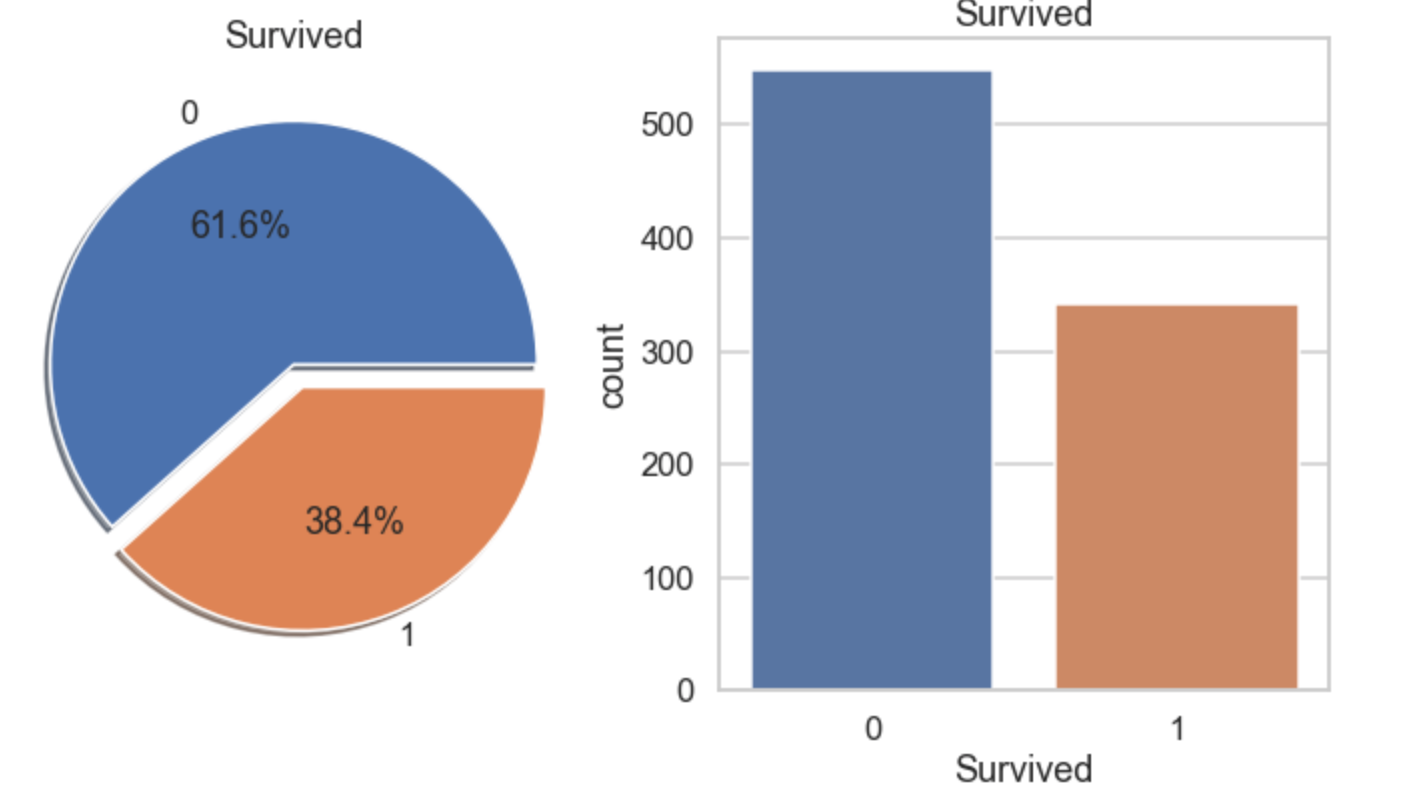


([<matplotlib.patches.Wedge at 0x16a311a90>,
 [Text(-0.3925747426847413, 1.027562684903461, '0'),
  Text(0.3925746464773772, -1.0275627216589567, '1')],
 [Text(-0.21413167782804068, 0.5604887372200695, '61.6%'),
  Text(0.21413162535129665, -0.5604887572685218, '38.4%')])

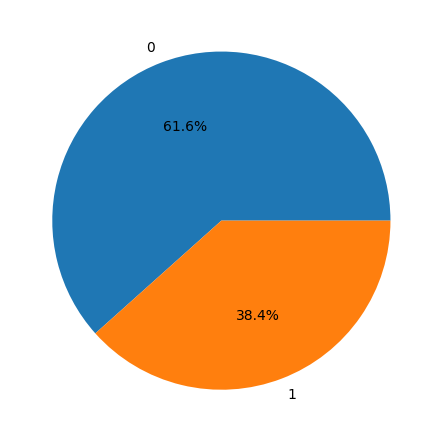

In [29]:
not_survived, survived = dataset['Survived'].value_counts()
total = dataset.shape[0]
not_survived_perc = not_survived / total * 100
survived_prec = survived / total * 100


plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.pie([not_survived_perc, survived_prec],  labels=['0', '1'], autopct='%1.1f%%')

На цьому графіку ми можемо побачити скільки процентів вижило , та скільки померло людей.Вижило 38.4% , померло 61,6%

Text(0.5, 1.0, 'Survived')

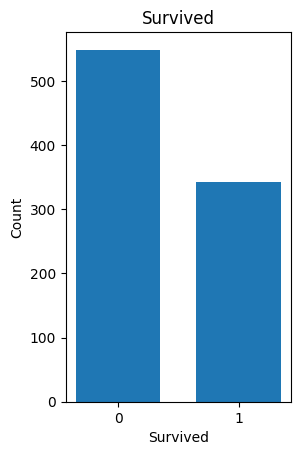

In [33]:
plt.subplot(122)
plt.bar(['0','1'], [not_survived,survived], width=0.7, )
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title("Survived")

Судячи по графіку вижило від 300 до 400(Приблизно 350) , а померло >500 , але менше ніж 600( приблизно 550)

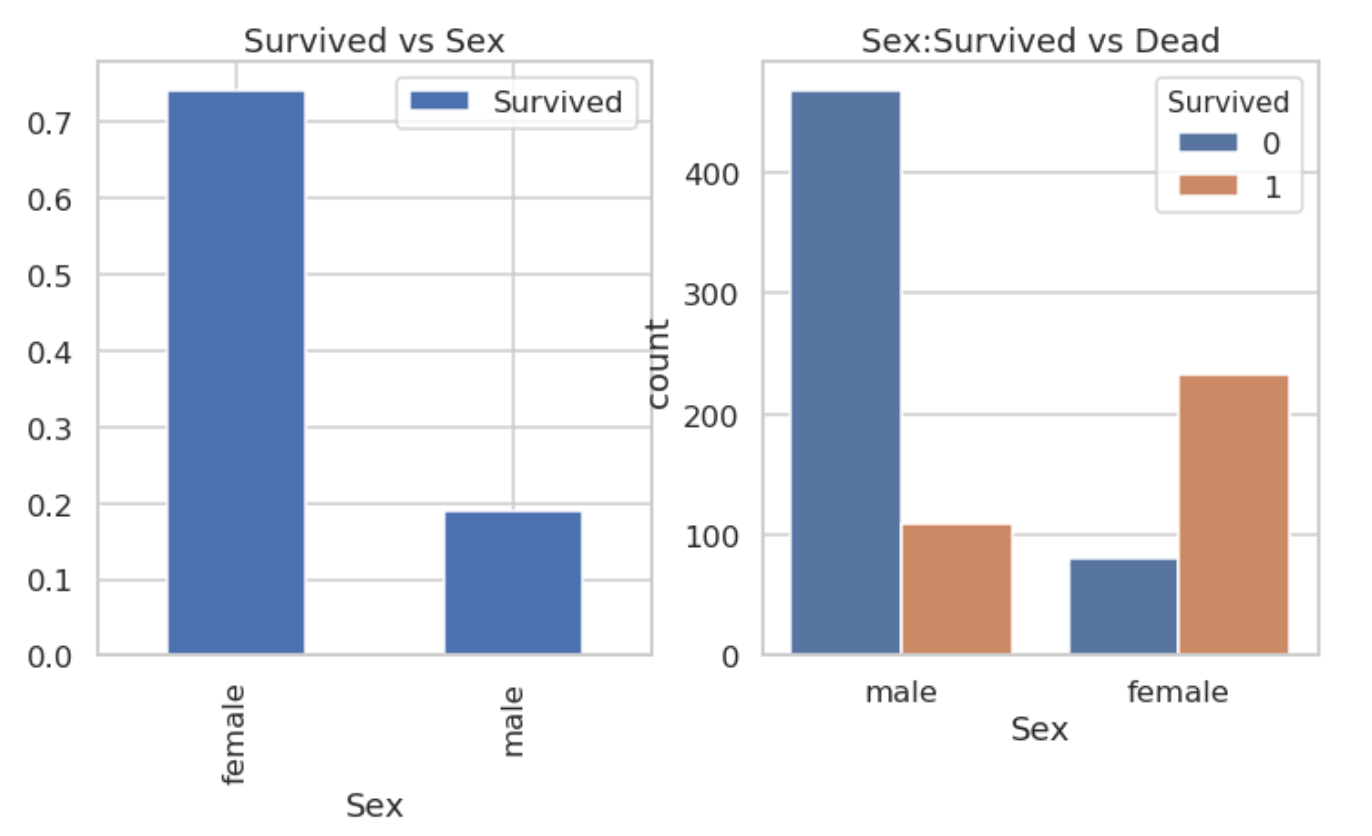

Text(0.5, 1.0, 'Survived vs Sex')

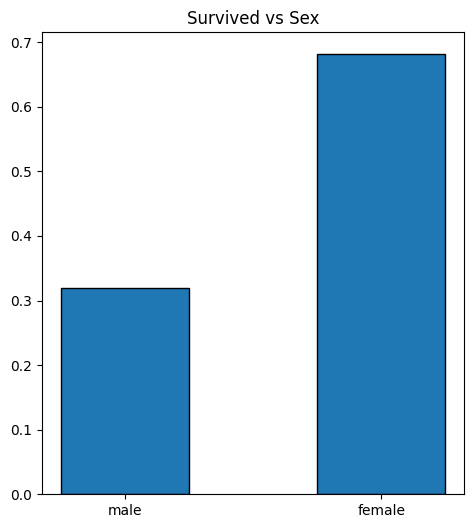

In [35]:
survived_general = dataset[dataset.Survived == 1]
male_female_survived = survived_general.Sex.value_counts()

male_in_persentage = male_female_survived.loc["male"] / (survived_general.shape[0])
female_in_persentage = male_female_survived.loc["female"] / (survived_general.shape[0])

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.bar(['male', 'female'], [male_in_persentage, female_in_persentage] , width=0.5, edgecolor='black')
plt.title("Survived vs Sex")


По графіку ми можемо побачити , що жінок вижило більше ніж чоловіків

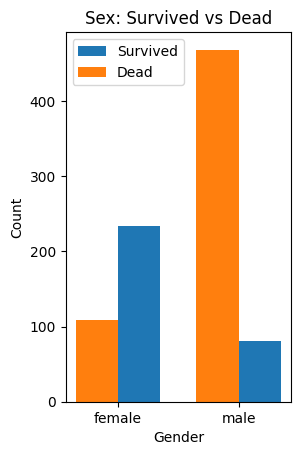

In [38]:
labels = ['female', 'male']
x = np.arange(len(labels))
dead = dataset[dataset['Survived'] == 0]
male_female_dead = dead.Sex.value_counts()
plt.subplot(122)
plt.bar(x+0.35, [male_female_survived.loc["female"], male_female_dead.loc["female"]], width=0.35, label='Survived')
plt.bar(x, [male_female_survived.loc["male"], male_female_dead.loc["male"]], width=0.35, label='Dead', )


plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Sex: Survived vs Dead')
plt.xticks(x + 0.35 / 2, labels)
plt.legend()

Смертність жінок була меншою ніж чоловіків

**Задача 3:** Скільки пропущених значень в датасеті по кожній із змінних? 

In [39]:
initial_dataset = pd.read_csv('titanic.csv')
columns = initial_dataset.columns



for column in columns:
    count_of_not_nan = initial_dataset[initial_dataset[column].isna()][column].shape[0]
    print(f"{column} has {count_of_not_nan} nan values")

PassengerId has 0 nan values
Survived has 0 nan values
Pclass has 0 nan values
Name has 0 nan values
Sex has 0 nan values
Age has 177 nan values
SibSp has 0 nan values
Parch has 0 nan values
Ticket has 0 nan values
Fare has 0 nan values
Cabin has 687 nan values
Embarked has 2 nan values


**Задача 4:** Назвіть найпопулярніше **жіноче** ім'я на кораблі. 

In [42]:
female_names = dataset[dataset["Sex"] == 'female']["Name"].copy()

def extract_first_name(name):
    if '(' in name:
        return name.split('(')[1].split(' ')[0]
    else:
        return name.split(',')[1].split(' ')[2]

female_names = female_names.apply(extract_first_name)

most_popular_name = female_names.value_counts().head(1)

print(f"Найпопулярніше жіноче ім'я є {most_popular_name.index[0]} яке повторюється {most_popular_name.iloc[0]} разів")


Найпопулярніше жіноче ім'я є Anna яке повторюється 14 разів


**Задача 5:** Назвіть найпопулярніше **чоловіче** ім'я на кораблі. 

In [44]:
male_names = dataset[dataset["Sex"] == 'male']["Name"].copy()

first_name = male_names.str.split(',').str[1].str.split(' ').str[2]

most_popular_name = first_name.value_counts()

print(f"Найпопулярніше чоловіче ім'я {most_popular_name.index[0]} з частотою {most_popular_name.iloc[0]} повторень")


Найпопулярніше чоловіче ім'я William з частотою 35 повторень


**Задача 6:** Побудуйте діаграми співвідношення загиблих та виживших за інформацією про те, квитки якого класу були у пасажирів.
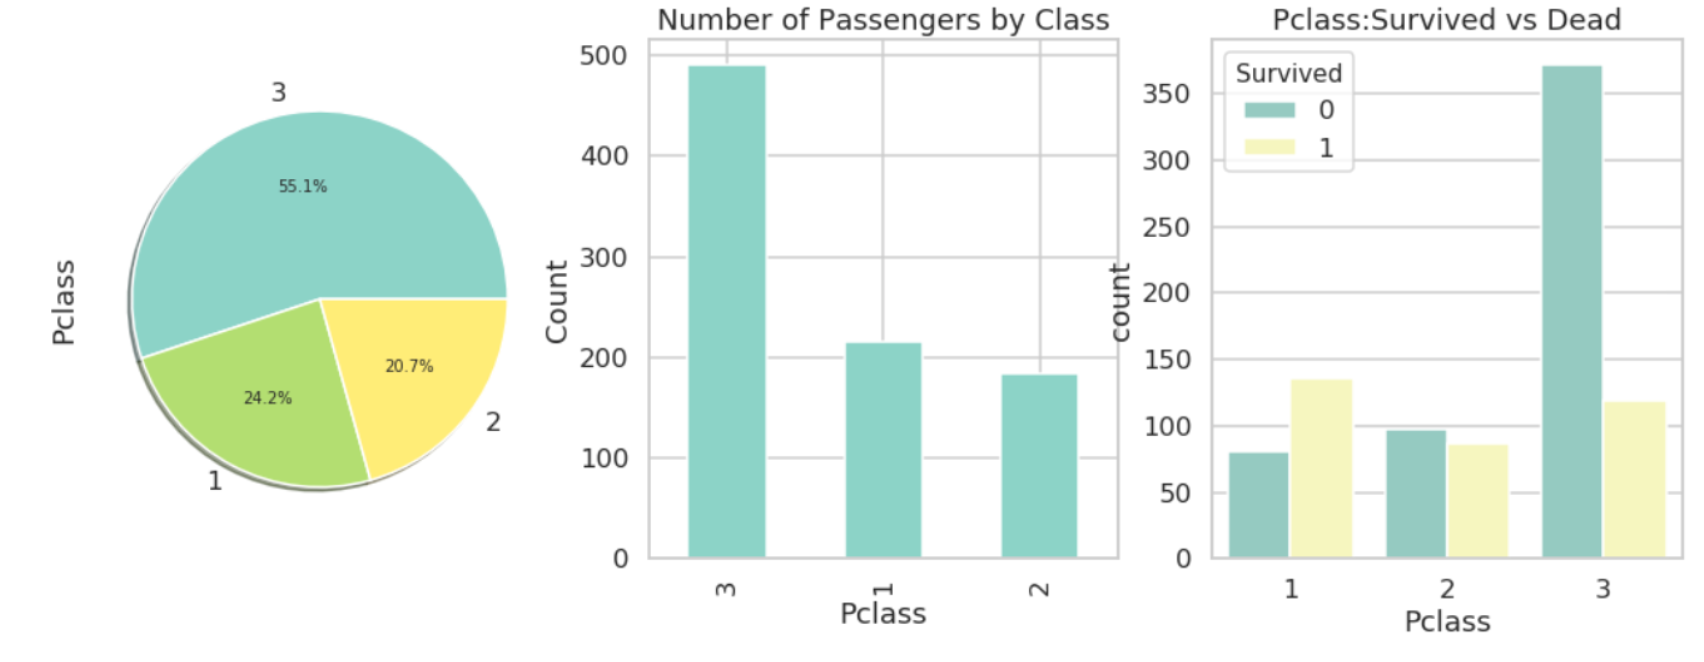

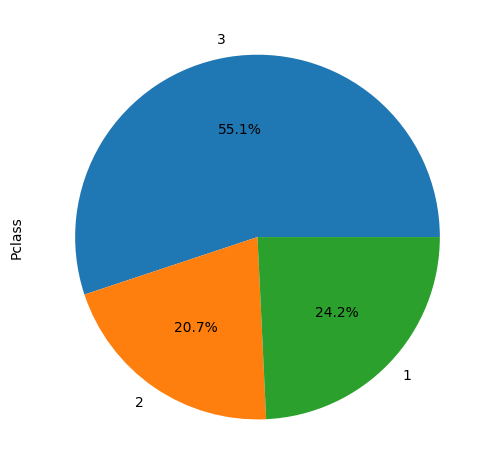

In [46]:
pclasses = dataset["Pclass"].value_counts().sort_index(ascending = False)
survived_count_by_class = dataset[dataset["Survived"] == 1].value_counts("Pclass").sort_index()
not_survived_count_by_class = dataset[dataset["Survived"] == 0].value_counts("Pclass").sort_index()


plt.figure(figsize=(20, 8))

plt.subplot(131)
plt.ylabel("Pclass")
plt.pie(pclasses, autopct='%1.1f%%', labels=pclasses.index)
plt.show()


Третього класу було найбільше та було 55.1% від загальної кількості

Text(0.5, 0, 'Pclass')

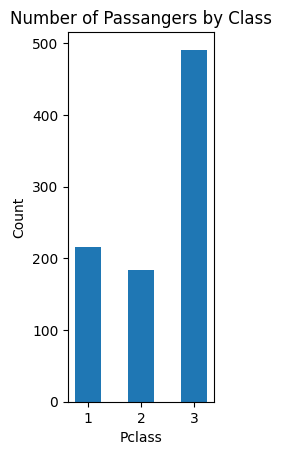

In [48]:
plt.subplot(132)
plt.bar(pclasses.index,  pclasses.values , width=0.5)
plt.xticks(range(1, len(pclasses.values)+1))
plt.title("Number of Passangers by Class")
plt.ylabel("Count")
plt.xlabel("Pclass")


На цьому графіку ми можем побачити що 491 особа - третій клас, 184 - другий клс, 216 - перший клас.

Text(0.5, 0, 'Pclass')

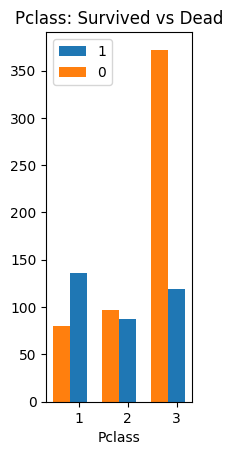

In [51]:
index = range(len(not_survived_count_by_class))

bar_width = 0.35
plt.subplot(133)
plt.bar([i + bar_width /2  for i in index], survived_count_by_class.values, width=bar_width, label="1")
plt.bar([i - bar_width/2  for i in index], not_survived_count_by_class.values, width=bar_width, label="0")
plt.xticks([i + bar_width / 2 for i in index], survived_count_by_class.index)
plt.legend(loc='upper left')
plt.title("Pclass: Survived vs Dead")
plt.xlabel("Pclass")

На цьому графіку ми можемо побачити що процентний показник смертності в 3 класі був найнижчим , а в першому найвищим 

**Задача 7:** Побудуйте наступні графіки та опишіть, що власне на них відображається.  
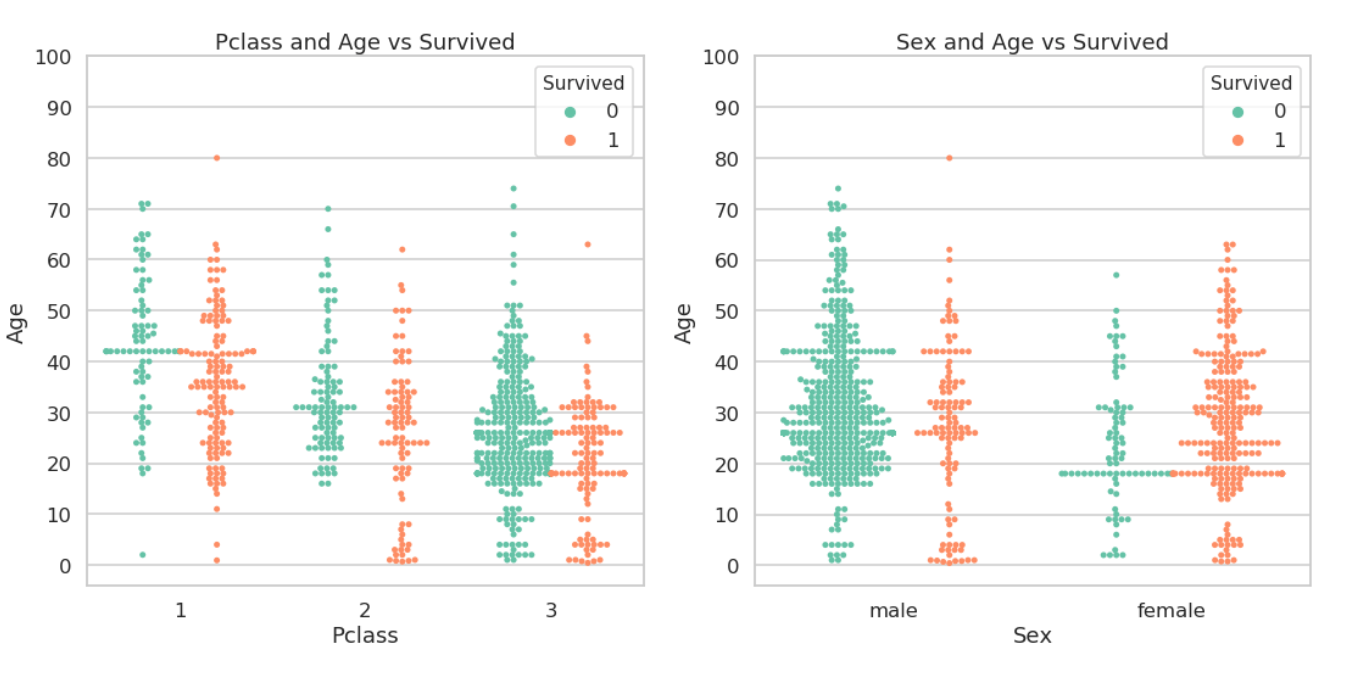![image.png](attachment:51486806-bd5d-4ae3-b95a-548aebf83de2.png)

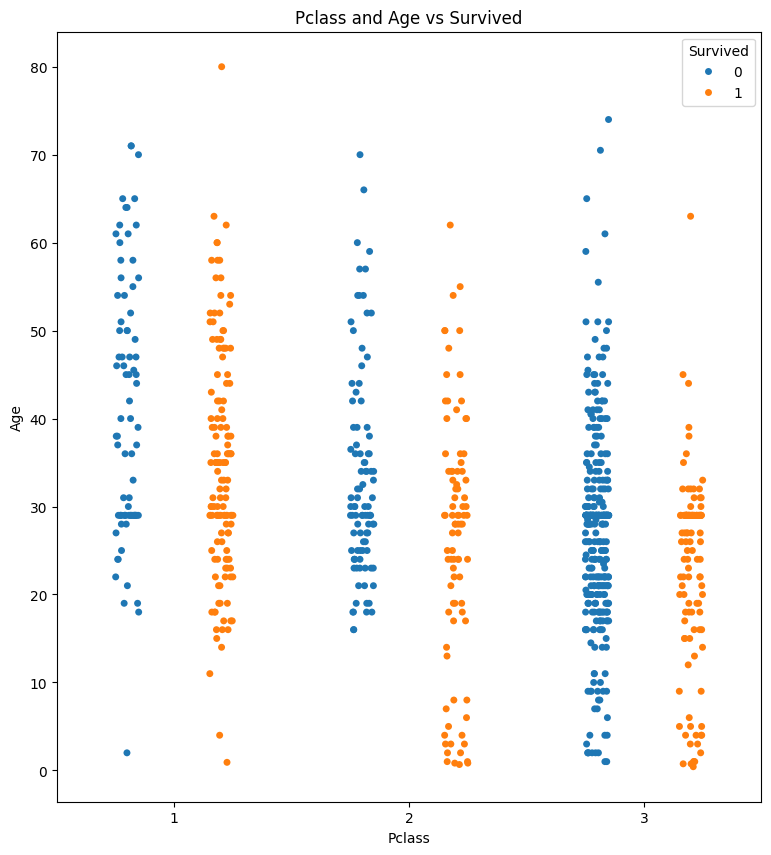

In [64]:
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.title("Pclass and Age vs Survived")
sns.stripplot(x='Pclass', y='Age', hue='Survived', data=shorten_dataset_class, dodge=True, edgecolor='black', jitter=True)
plt.show()



Ми можемо побачити співвідношення між людьми які вижитили та померли за їхнім віком , та класами 

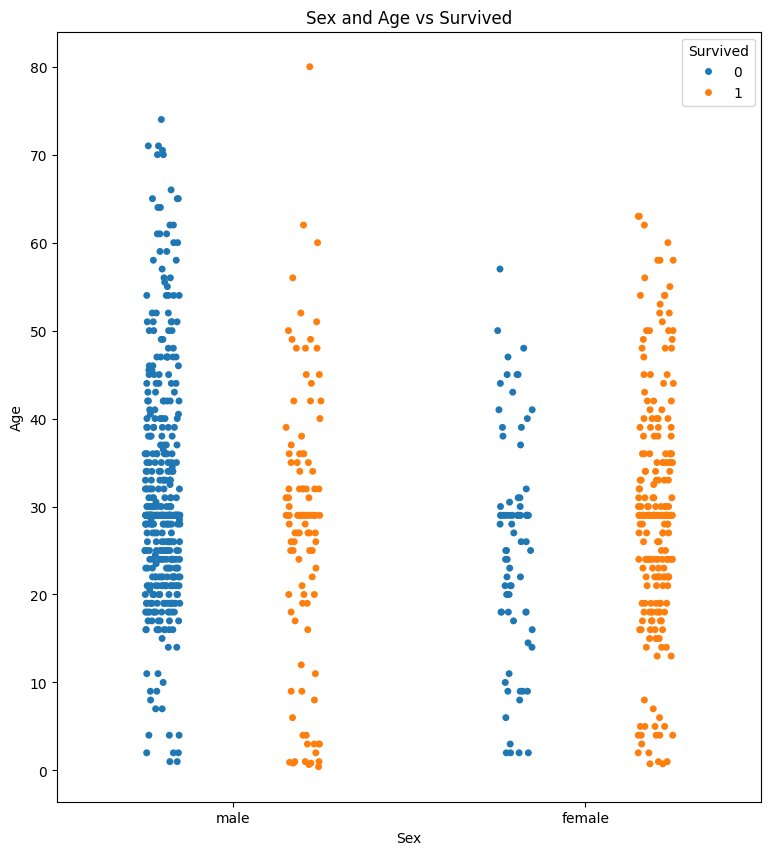

In [66]:
plt.figure(figsize=(20, 10))
plt.subplot(122)
plt.title('Sex and Age vs Survived')
sns.stripplot(x='Sex', y='Age', hue='Survived', data=shorten_dataset_sex, dodge=True, edgecolor='black', jitter=True)

plt.show()

Смертність жінок ,  дітей , та підлітків була набагато меншою ніж дорослих чоловіків


Прокоментуйте побудовані графіки

**Задача 8** Побудуйте наступні діаграми розподілів:  

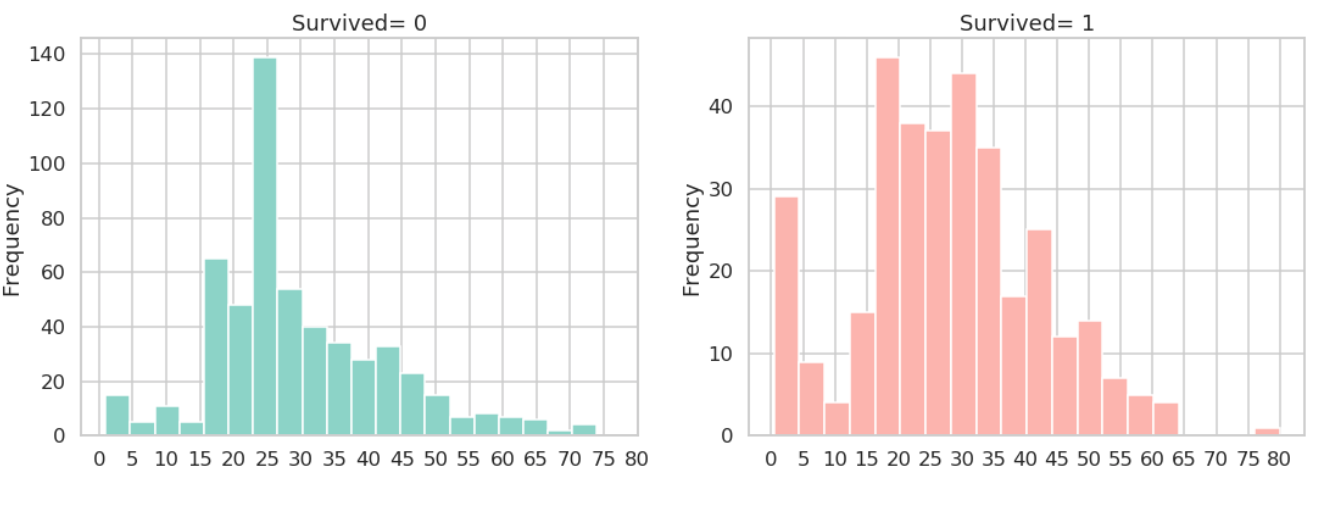



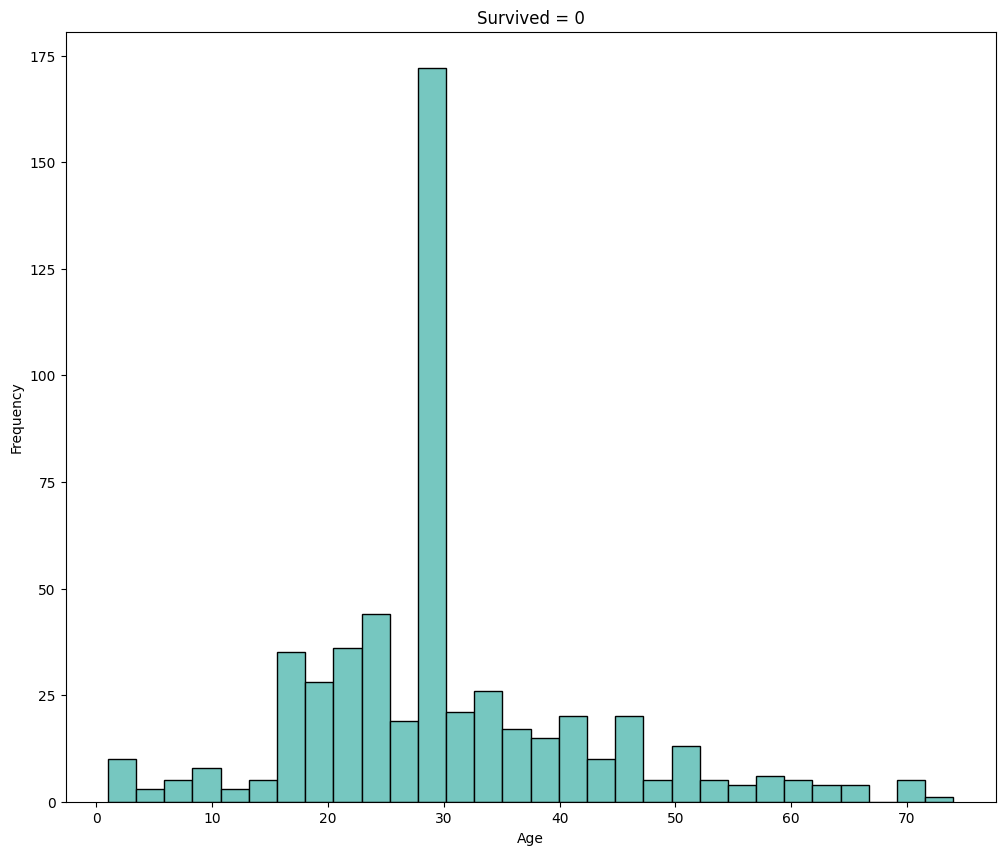

In [86]:
filtered_dataset_dead = dataset[dataset["Survived"] == 0]
filtered_dataset_survived = dataset[dataset["Survived"] == 1]


max_age = int(max(dataset['Age']))
plt.figure(figsize=(12, 10))

plt.ylabel('Frequency')
plt.title('Survived = 0')

sns.histplot(dataset[dataset['Survived'] == 0].Age, bins=30, kde=False, color='#76C7C0', alpha=1)

plt.show()


Найбільше померло людей віком від 15-40 років, пык був на позначці 25-30 років

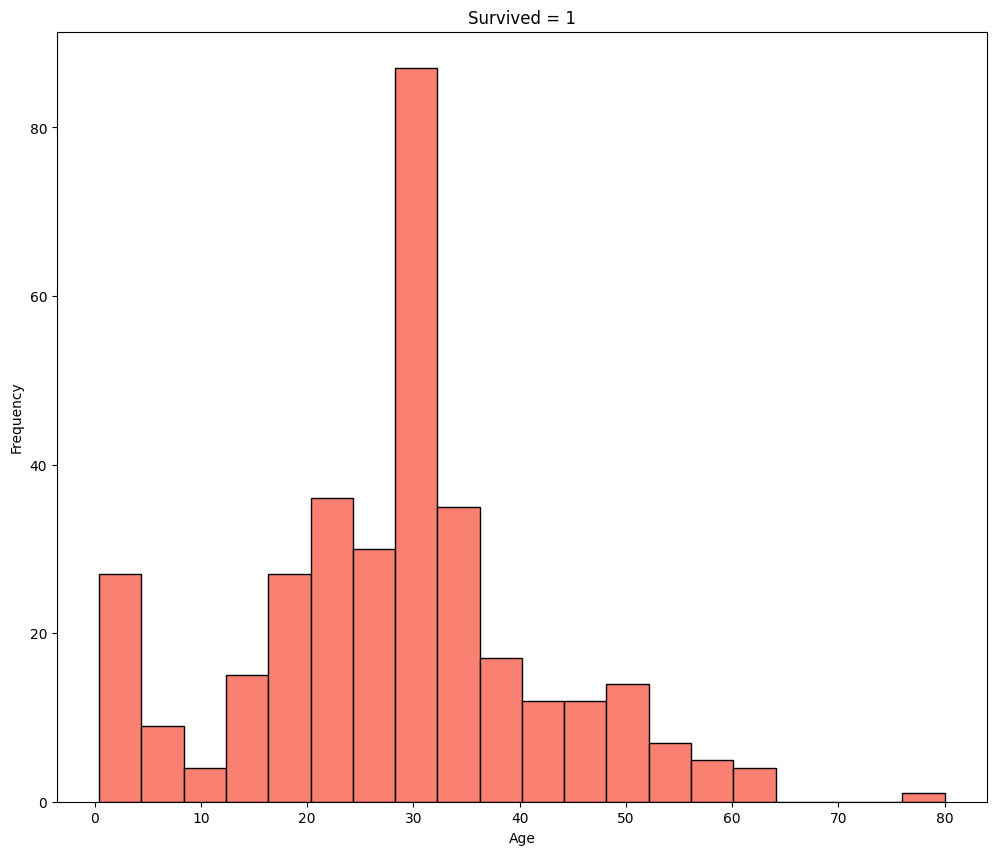

In [112]:
plt.figure(figsize=(12, 10))

plt.ylabel('Frequency')
plt.title('Survived = 1')

sns.histplot(dataset[dataset['Survived'] == 1].Age, bins=20, color='salmon', kde=False, alpha=1)

plt.show()

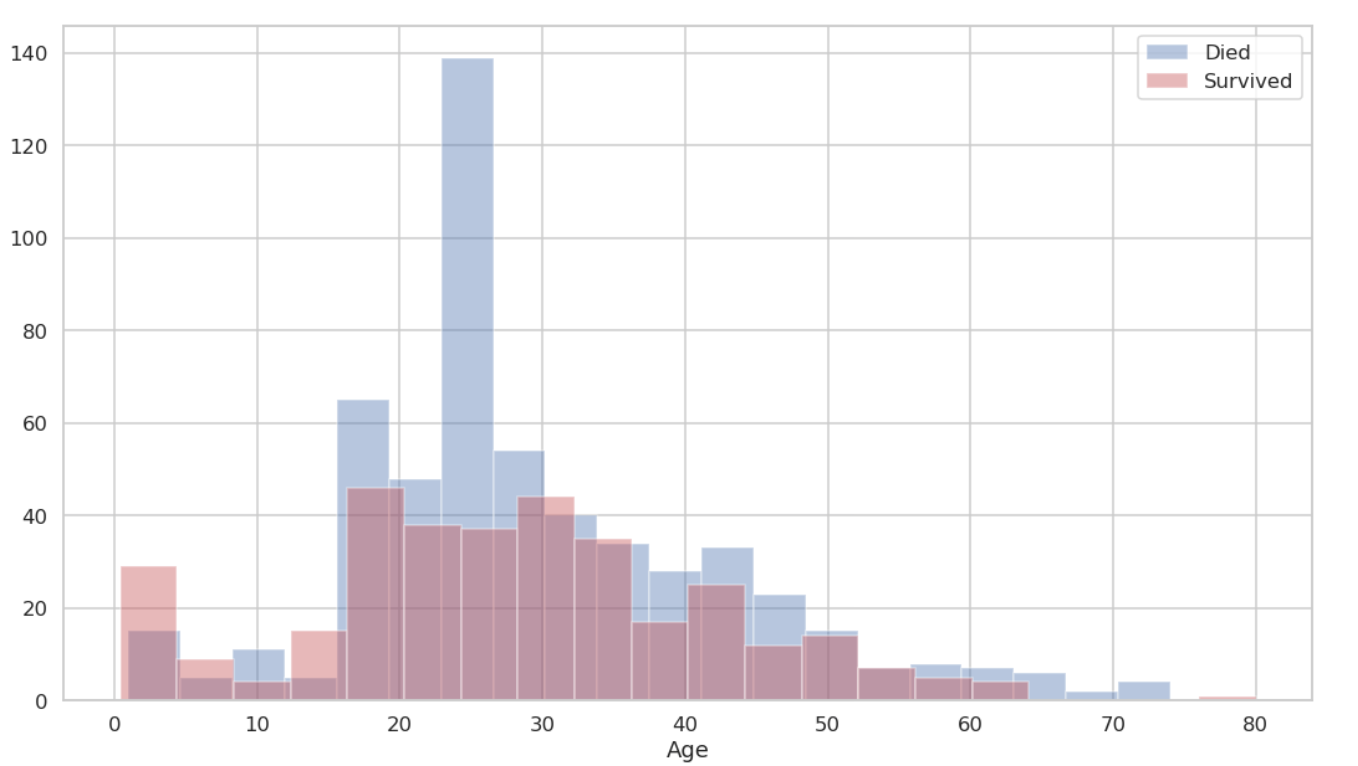

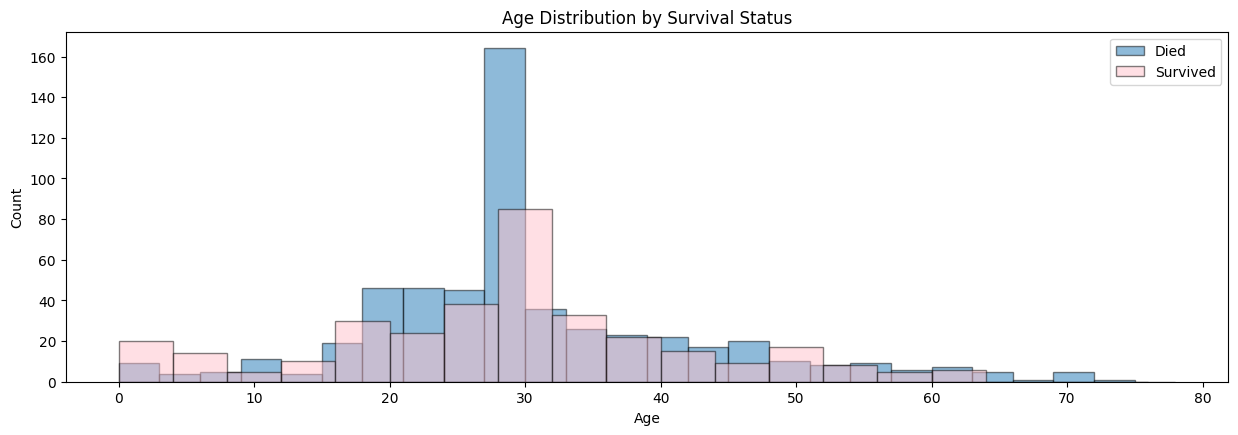

In [87]:
plt.figure(figsize=(15, 10))
plt.subplot(211)

plt.hist(filtered_dataset_dead.Age, bins=range(0, max_age, 3), alpha=0.5, label='Died', edgecolor='black')
plt.hist(filtered_dataset_survived.Age, bins=range(0, max_age, 4), alpha=0.5, label='Survived', color='pink', edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Survival Status')
plt.legend()

Тут нам легше зрозуміти статистику , та зрозуміти +- в якому процентному відношенні були загиблі до тих хто вижив.Наприклад ми можемо побачити що людей віком від 65 до 75 померло в процентному відношенні більше ніж від 20 до 40. Але якщо брати кількість то різниця смертей від 20 до 40 набагато більша ніж кількість смертей пенсіонерів. Це нам допомагає краще зрозуміти статистику розглянувши процентне відношення

**Задача 9:** Побудуйте наступні діаграми та проведіть аналітику шансів на виживання серед пасажирів:  
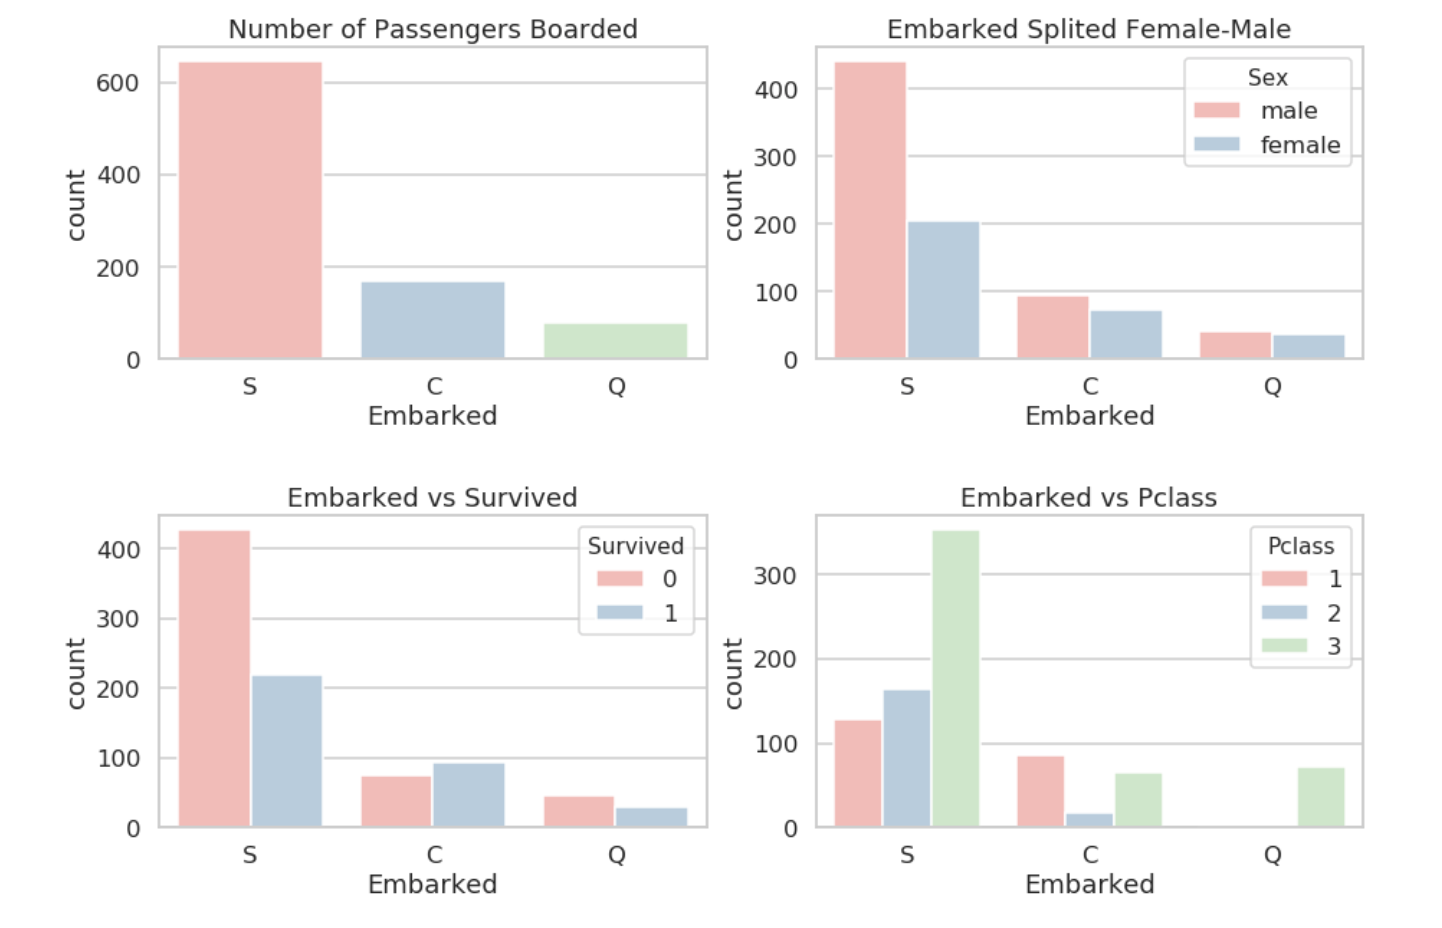

Text(0, 0.5, 'Count')

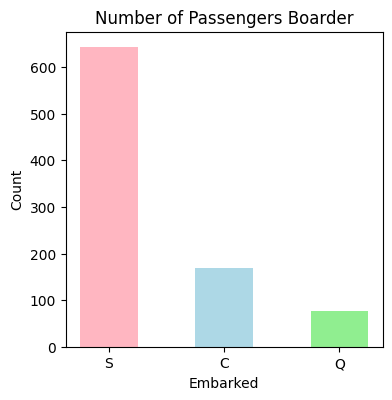

In [110]:
passenger_by_embarked = dataset['Embarked'].value_counts().sort_values(ascending=False)


plt.subplot(221)
plt.bar(passenger_by_embarked.index, passenger_by_embarked.values, width=0.5, color = ['lightpink', 'lightblue', 'lightgreen'])
plt.title("Number of Passengers Boarder")
plt.xlabel("Embarked")
plt.ylabel("Count")

Text(0.5, 1.0, 'Embarked Splited Female-Male')

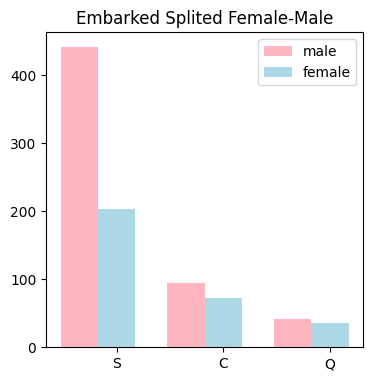

In [105]:
embarked_by_male = dataset[dataset['Sex'] == 'male']['Embarked'].value_counts().sort_values(ascending=False)
embarked_by_female= dataset[dataset['Sex'] == 'female']['Embarked'].value_counts().sort_values(ascending=False)
index = range(len(embarked_by_male))

bar_width = 0.35
plt.subplot(222)
plt.bar([i - bar_width / 2  for i in index], embarked_by_male.values, width=bar_width, color = 'lightpink', label="male")
plt.bar([i +bar_width / 2  for i in index], embarked_by_female.values, width=bar_width, color = 'lightblue', label="female")
plt.xticks([i + bar_width / 2 for i in index], embarked_by_male.index)
plt.legend(loc='upper right')
plt.title("Embarked Splited Female-Male")

Text(0.5, 1.0, 'Embarked vs Survived')

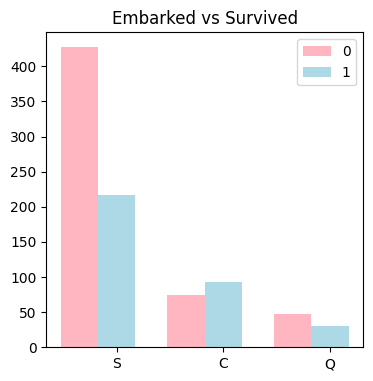

In [106]:
embarked_survived = dataset[dataset['Survived'] == 1]['Embarked'].value_counts().sort_values(ascending=False)
embarked_not_survived= dataset[dataset['Survived'] == 0]['Embarked'].value_counts().sort_values(ascending=False)

index = range(len(embarked_survived))
plt.subplot(223)

plt.bar([i - bar_width / 2  for i in index], embarked_not_survived.values, width=bar_width, color = 'lightpink', label="0")
plt.bar([i + bar_width / 2  for i in index], embarked_survived.values, width=bar_width, color = 'lightblue', label="1")
plt.xticks([i + bar_width / 2 for i in index], embarked_survived.index)
plt.legend(loc='upper right')
plt.title("Embarked vs Survived")

Text(0.5, 1.0, 'Embarked vs Pclass')

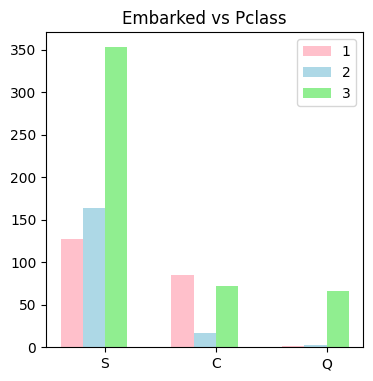

In [109]:
bar_width = 0.2
embarked_by_pclass_1 = dataset[dataset['Pclass'] == 1]['Embarked'].value_counts().sort_values(ascending=False)
embarked_by_pclass_2 = dataset[dataset['Pclass'] == 2]['Embarked'].value_counts().sort_values(ascending=False)
embarked_by_pclass_3 = dataset[dataset['Pclass'] == 3]['Embarked'].value_counts().sort_values(ascending=False)

index = range(len(embarked_by_pclass_1))
plt.subplot(224)

plt.bar([i - bar_width for i in index], embarked_by_pclass_1, width=bar_width, color='pink', label="1")
plt.bar(index, embarked_by_pclass_2, width=bar_width, color='lightblue', label="2")
plt.bar([i + bar_width for i in index], embarked_by_pclass_3, width=bar_width, color='lightgreen', label="3")
plt.xticks([i + bar_width / 2 for i in index], embarked_by_pclass_1.index)

plt.legend(loc='upper right')
plt.title("Embarked vs Pclass")

в (S) сіло найбільше пасажирів третього класу , що значно перевищує кількість пасажирів першого та другого  класів.
в (C) також сіло більше пасажирів першого класу, ніж інших класів.
в (Q) переважна більшість пасажирів були третього класу.
Пасажири, які були  в першому класі, мали кращі шанси на виживання порівняно з пасажирами з інших портів і класів.

***Завдача 10** Побудуйте діаграму розподілу ```вартості квитка``` відповідно до якого классу належіть пасажир.

Text(0, 0.5, 'Frequency')

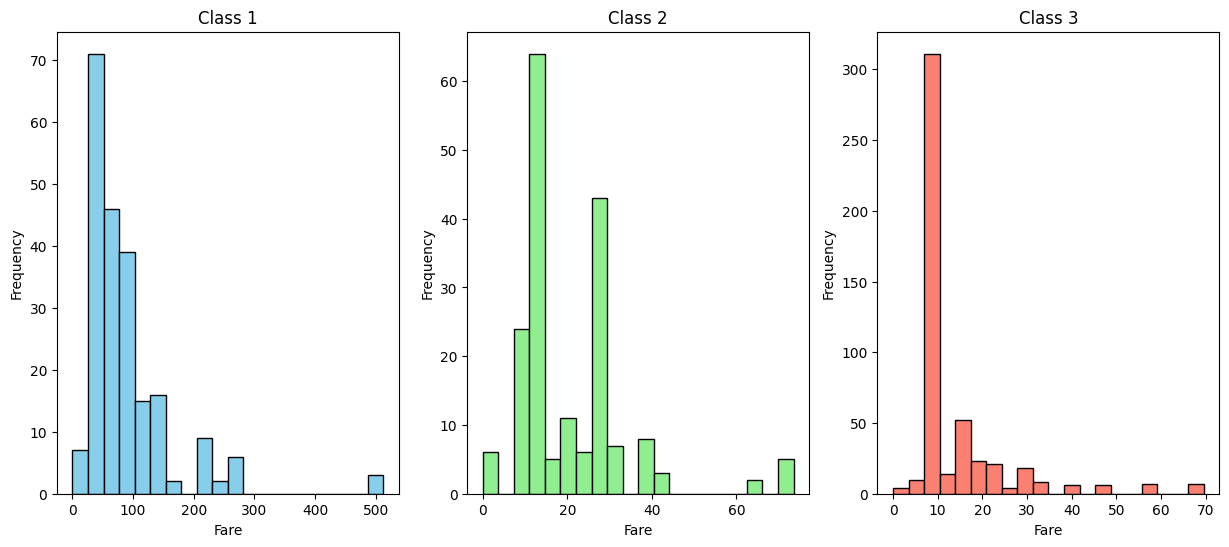

In [111]:

class_1 = dataset[dataset['Pclass'] == 1]
class_2 = dataset[dataset['Pclass'] == 2]
class_3 = dataset[dataset['Pclass'] == 3]

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.hist(class_1['Fare'], bins=20, color='lightblue', edgecolor='black')
plt.title('Class 1')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(class_2['Fare'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Class 2')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(class_3['Fare'], bins=20, color='salmon', edgecolor='black')
plt.title('Class 3')
plt.xlabel('Fare')
plt.ylabel('Frequency')

Перший графік показує ціни на квитки в першому класі. Найдорожчий коштував 500$, а більшість купували за 70$.

Другий графік показує ціни на квитки в другому класі. Найдорожчі були 70-80$, а більшість купували приблизно за 70$.

Третій графік показує ціни на квитки в третьому класі. Найдорожчі були близько 70$, а більшість купували за 8-10$, понад 300 людей.